# Descripción de los datos


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 110

DATA = Path("../data/train.csv")
OUT = Path("../output"); OUT.mkdir(exist_ok=True)

assert DATA.exists(), (
    "Falta data/train.csv. Descargarlo de "
    "https://www.kaggle.com/competitions/nlp-getting-started/data y colocarlo en data/."
)
df = pd.read_csv(DATA)
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


## 1. Dimensiones y diccionario de variables

In [2]:
print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
df.info()

Filas: 7,613  |  Columnas: 5
<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


In [3]:
diccionario = pd.DataFrame({
    "variable": ["id", "keyword", "location", "text", "target"],
    "tipo": [str(df[c].dtype) for c in ["id","keyword","location","text","target"]],
    "rol": ["identificador","predictora","predictora","predictora (principal)","objetivo"],
    "descripcion": [
        "Identificador único del tweet",
        "Palabra clave del tweet (puede estar vacía)",
        "Ubicación declarada del autor (texto libre, puede estar vacía)",
        "Texto del tweet",
        "1 = desastre real, 0 = no",
    ],
})
diccionario

,variable,tipo,rol,descripcion
0,id,int64,identificador,Identificador único del tweet
1,keyword,str,predictora,Palabra clave del tweet (puede estar vacía)
2,location,str,predictora,"Ubicación declarada del autor (texto libre, puede estar vacía)"
3,text,str,predictora (principal),Texto del tweet
4,target,int64,objetivo,"1 = desastre real, 0 = no"


## 2. Valores faltantes

In [4]:
na = pd.DataFrame({
    "n_nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
})
na

,n_nulos,pct_nulos
id,0,0.00
keyword,61,0.80
location,2533,33.27
text,0,0.00
target,0,0.00


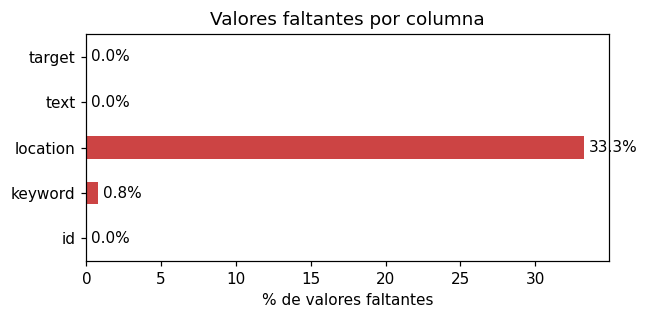

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))
na["pct_nulos"].plot.barh(ax=ax, color="#c44")
ax.set_xlabel("% de valores faltantes"); ax.set_title("Valores faltantes por columna")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.tight_layout(); plt.savefig(OUT / "faltantes.png"); plt.show()

## 3. Variable objetivo `target` (balance de clases)

In [6]:
vc = df["target"].value_counts().sort_index()
bal = pd.DataFrame({"conteo": vc, "proporcion": (vc / len(df)).round(4)})
bal.index = ["0 - no desastre", "1 - desastre real"]
print(bal)
print(f"\nRatio 0:1 = {vc[0] / vc[1]:.2f}")

                   conteo  proporcion
0 - no desastre      4342      0.5703
1 - desastre real    3271      0.4297

Ratio 0:1 = 1.33


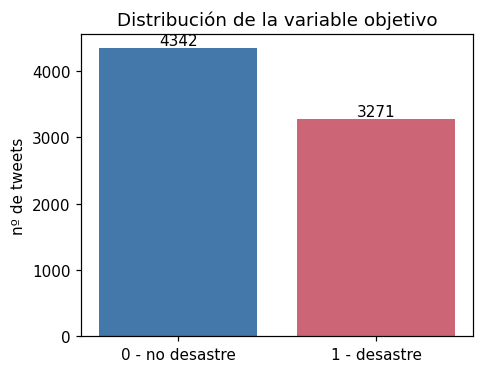

In [7]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.bar(["0 - no desastre", "1 - desastre"], vc.values, color=["#4477aa", "#cc6677"])
ax.bar_label(ax.containers[0])
ax.set_ylabel("nº de tweets"); ax.set_title("Distribución de la variable objetivo")
plt.tight_layout(); plt.savefig(OUT / "balance_target.png"); plt.show()

## 4. Análisis de la columna `text`

Longitud en caracteres y en palabras, y detección (solo conteo, sin limpiar) de URLs,
menciones `@`, hashtags `#` y emojis.

In [8]:
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#\w+")
EMOJI_RE = re.compile(
    "[" "\U0001F300-\U0001FAFF" "\U00002600-\U000027BF" "\U0001F1E6-\U0001F1FF" "]"
)

df["has_url"] = df["text"].str.contains(URL_RE)
df["has_mention"] = df["text"].str.contains(MENTION_RE)
df["has_hashtag"] = df["text"].str.contains(HASHTAG_RE)
df["has_emoji"] = df["text"].str.contains(EMOJI_RE)

df[["n_chars", "n_words"]].describe().round(2)

,n_chars,n_words
count,7613.00,7613.00
mean,101.04,14.90
std,33.78,5.73
min,7.00,1.00
25%,78.00,11.00
50%,107.00,15.00
75%,133.00,19.00
max,157.00,31.00


In [9]:
marcadores = pd.DataFrame({
    "n_tweets": [df["has_url"].sum(), df["has_mention"].sum(),
                 df["has_hashtag"].sum(), df["has_emoji"].sum()],
})
marcadores.index = ["con URL", "con @mención", "con #hashtag", "con emoji"]
marcadores["pct"] = (marcadores["n_tweets"] / len(df) * 100).round(2)
marcadores

,n_tweets,pct
con URL,3971,52.16
con @mención,2009,26.39
con #hashtag,1743,22.90
con emoji,0,0.00


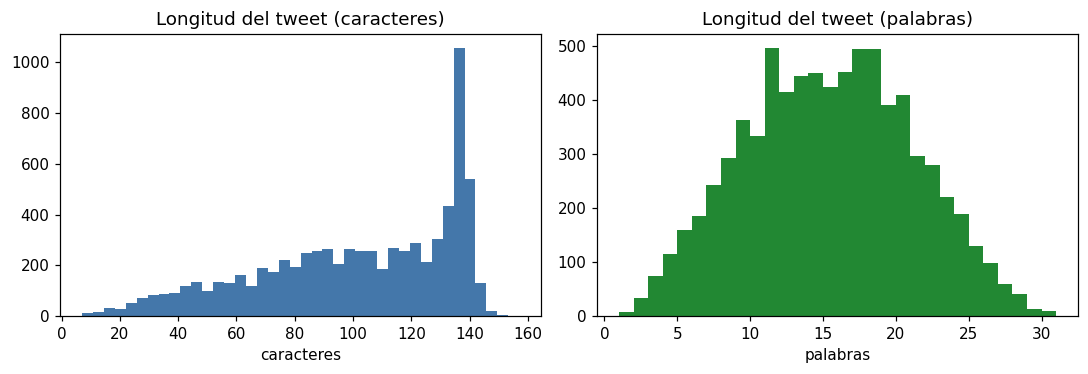

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(df["n_chars"], bins=40, color="#4477aa")
axes[0].set_title("Longitud del tweet (caracteres)"); axes[0].set_xlabel("caracteres")
axes[1].hist(df["n_words"], bins=30, color="#228833")
axes[1].set_title("Longitud del tweet (palabras)"); axes[1].set_xlabel("palabras")
plt.tight_layout(); plt.savefig(OUT / "longitud_texto.png"); plt.show()

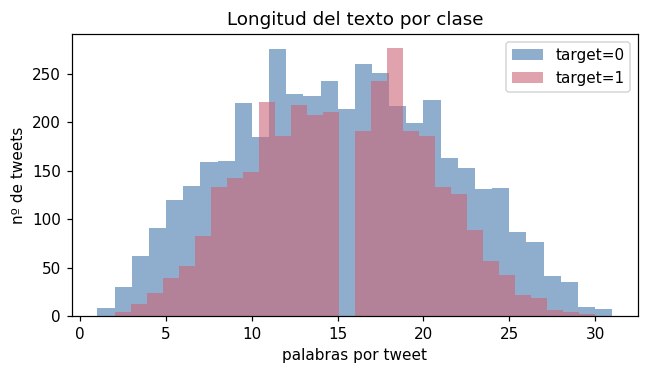

,n_chars,n_words
target,,
0,95.71,14.70
1,108.11,15.17


In [11]:
# Longitud por clase
fig, ax = plt.subplots(figsize=(6, 3.5))
for t, color in [(0, "#4477aa"), (1, "#cc6677")]:
    ax.hist(df.loc[df.target == t, "n_words"], bins=30, alpha=0.6,
            label=f"target={t}", color=color)
ax.set_xlabel("palabras por tweet"); ax.set_ylabel("nº de tweets")
ax.set_title("Longitud del texto por clase"); ax.legend()
plt.tight_layout(); plt.savefig(OUT / "longitud_por_clase.png"); plt.show()

df.groupby("target")[["n_chars", "n_words"]].mean().round(2)

## 5. Columna `keyword`

In [12]:
print(f"Valores únicos de keyword: {df['keyword'].nunique()}")
print(f"Formato con '%20' (espacios): {df['keyword'].str.contains('%20', na=False).sum()} filas")
df["keyword"].value_counts().head(15)

Valores únicos de keyword: 221
Formato con '%20' (espacios): 1165 filas


keyword
fatalities     45
armageddon     42
deluge         42
body%20bags    41
damage         41
harm           41
sinking        41
collided       40
evacuate       40
fear           40
outbreak       40
siren          40
twister        40
windstorm      40
collision      39
Name: count, dtype: int64

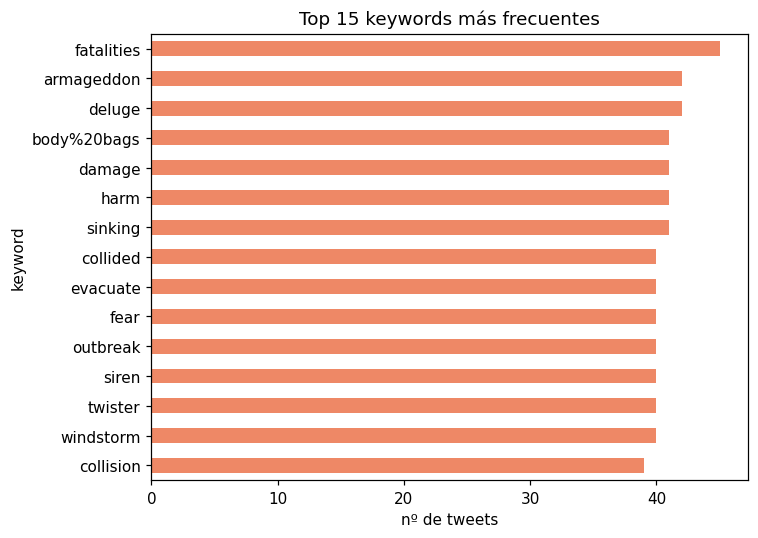

In [13]:
top_kw = df["keyword"].value_counts().head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 5))
top_kw.plot.barh(ax=ax, color="#ee8866")
ax.set_xlabel("nº de tweets"); ax.set_title("Top 15 keywords más frecuentes")
plt.tight_layout(); plt.savefig(OUT / "top_keywords.png"); plt.show()

In [14]:
# keyword vs target: keywords con mayor y menor proporción de desastre
kw_rate = (df.dropna(subset=["keyword"])
             .groupby("keyword")["target"].agg(["mean", "count"])
             .query("count >= 20").sort_values("mean"))
print("Keywords MÁS asociadas a NO-desastre:")
print(kw_rate.head(10).round(3))
print("\nKeywords MÁS asociadas a desastre real:")
print(kw_rate.tail(10).round(3))

Keywords MÁS asociadas a NO-desastre:
              mean  count
keyword                  
aftershock   0.000     34
body%20bags  0.024     41
ruin         0.027     37
blazing      0.029     34
body%20bag   0.030     33
electrocute  0.031     32
screaming    0.056     36
traumatised  0.057     35
panicking    0.061     33
blew%20up    0.061     33

Keywords MÁS asociadas a desastre real:
                    mean  count
keyword                        
suicide%20bomb     0.914     35
bombing            0.931     29
suicide%20bomber   0.968     31
suicide%20bombing  0.970     33
oil%20spill        0.974     38
typhoon            0.974     38
outbreak           0.975     40
derailment         1.000     39
wreckage           1.000     39
debris             1.000     37


## 6. Columna `location`

In [15]:
print(f"Valores únicos de location: {df['location'].nunique()}")
print(f"Nulos: {df['location'].isna().sum()} ({df['location'].isna().mean()*100:.1f}%)")
df["location"].value_counts().head(15)

Valores únicos de location: 3341
Nulos: 2533 (33.3%)


location
USA                104
New York            71
United States       50
London              45
Canada              29
Nigeria             28
UK                  27
Los Angeles, CA     26
India               24
Mumbai              22
Washington, DC      21
Kenya               20
Worldwide           19
Australia           18
Chicago, IL         18
Name: count, dtype: int64

La columna es **texto libre sin normalizar** (mezcla países, ciudades, estados, frases y
valores sin sentido geográfico). Alta cardinalidad + un tercio de nulos ⇒ poco aprovechable
sin una limpieza/geocodificación dedicada.

## 7. Duplicados y etiquetas inconsistentes

In [16]:
dup_text = df.duplicated(subset=["text"]).sum()
print(f"Filas con 'text' duplicado: {dup_text}")

# Mismo texto con etiquetas distintas
conflictivos = (df.groupby("text")["target"].nunique()
                  .loc[lambda s: s > 1].index)
print(f"Textos idénticos con target contradictorio: {len(conflictivos)}")
df[df["text"].isin(conflictivos)].sort_values("text")[["text", "target"]].head(10)

Filas con 'text' duplicado: 110
Textos idénticos con target contradictorio: 18


,text,target
4290,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in ...,0
4299,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in ...,0
4312,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in ...,1
4244,#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption,0
4221,#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption,1
4239,#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption,1
2832,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https...,0
2831,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https...,1
2830,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https...,1
2833,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https...,1


## 8. Ejemplos por clase

In [17]:
for t in (1, 0):
    etiqueta = "DESASTRE REAL" if t else "NO DESASTRE"
    print(f"\n {etiqueta} (target={t}) \n")
    for txt in df.loc[df.target == t, "text"].head(4):
        print(" •", txt)


 DESASTRE REAL (target=1) 

 • Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
 • Forest fire near La Ronge Sask. Canada
 • All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
 • 13,000 people receive #wildfires evacuation orders in California 

 NO DESASTRE (target=0) 

 • What's up man?
 • I love fruits
 • Summer is lovely
 • My car is so fast
